### CS4423 - Networks
Anton Baykalov  
School of Mathematical and Statistical Sciences  
University of Galway  

[![Open in Binder](images/badge_logo.png)](https://mybinder.org/v2/gh/anton-baykalov/networks/HEAD)

https://mybinder.org/v2/gh/anton-baykalov/networks/HEAD

#### 5. Small Worlds

# Week 9, lecture 1: Phase transitions: Giant Component.

# Characteristic Path Length. Clustering.

In [1]:
import networkx as nx
opts = { "with_labels" : True, "node_color": 'y' }

We have seen that the threshold probability for the appearance of a *connected* subgraph $F$ of order $a$ and size $b$ is 

$$p_F(n)=n^{-\frac{a}{b}},$$
meaning that

* If $p(n)$ decays **faster** than $p_F(n)$ (think: in our $G(n,p(n))$ the likelihood of a certain edge is lower than in the threshold case) then almost every graph sampled from  $G(n,p(n))$ does **not** have $F$ as a subgraph;

* If $p(n)$ decays **slower** than $p_F(n)$ (think: in our $G(n,p(n))$ the likelihood of a certain edge is higher than in the threshold case) then almost every graph sampled from  $G(n,p(n))$ **does** have $F$ as a subgraph;

* If $p(n)=c n^{-\frac{a}{b}}$ for some constant $c$, then we can find an explicit expression for the expected number of occurrences of the subgraph $F$ in a graph sampled from $G(n,p(n))$. 

For example:

* **Trees**  with $a$ nodes ($b = a - 1$) appear when $p(n) = c n^{-a/(a-1)}$.
* **Cycles** of order $a$ (where $b = a$) appear when $p(n) = c n^{-1}$.
* **Complete** subgraphs of order $a$ (where $b = \binom{a}{2} = \frac12 a(a-1)$) appear when $p(n) = c n^{-2/(a-1)}$.

In practice, we can estimate $n_F$ as follows:
* there are $\binom{n}{a}$ ways to pick $a$ nodes from a graph $G$ on $n$ nodes;
* between them, $b$ links are present with probability $p^b$;
* permuting the $a$ nodes of $F$ yields $a!/|\mathrm{Aut}(F)|$ copies of this configuration.

That is, in total there are 
$$
n_F = \frac{n!}{a!(n-a)!}p^b \cdot\frac{a!}{ |\mathrm{Aut}(F)|} =$$ $$ = \frac{n! p^b}{(n-a)! |\mathrm{Aut}(F)|} \approx \frac{n^a p^b}{|\mathrm{Aut}(F)|}
$$
copies of $F$ in $G$.
* Note how this number depends only on $a$ and $b$.

**Example.** Numbers of 
* triads (trees on 3 vertices) with $a = 3$, $b = 2$ and $|\mathrm{Aut}(F)| = 2$.  $$3 \binom{n}{3} p^2 = \tfrac12 n(n-1)(n-2)p^2 \approx \frac12 n^3 p^2,$$

* triangles where $a = b = 3$ and $|\mathrm{Aut}(F)| = 6$: $\binom{n}{3} p^3 = \tfrac16 n(n-1)(n-2)p^3 \approx \frac16 n^3 p^3$.

* star graph with $a = 4$, $b =3$ and $|\mathrm{Aut}(F)| = 6$: $$4 \binom{n}{4} p^3 = \tfrac16 n(n-1)(n-2)(n-3) p^3 \approx \tfrac16 n^4 p^3,$$

### **Connectivity** 

$p(n) = \frac1n \ln n$ is the threshold probability for $G$ to be connected. 
(This corresponds to $m = \frac12 n \ln n$ in model $A$.)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# n values (start from 1 to avoid ln(0))
n = np.linspace(1, 200, 500)

# function
f = np.log(n) / n

# plot
plt.plot(n, f)
plt.xlabel("n")
plt.ylabel("ln(n) / n")
plt.title("Graph of (ln n)/n")
plt.grid(True)

plt.show()

##  The Giant Connected Component

**Definition (Giant Component).**
A connected component of a graph $G$ is called a **giant component**
if its number of nodes increases with the order $n$ of $G$ as
some positive power of $n$.

Suppose $p(n) = cn^{-1}$ for some positive constant $c$.  (Then the average degree $\langle k \rangle = pn = c$ remains fixed as $n \to \infty$.)

**Theorem (Erdős-Rényi)**.
* If $c < 1$ the graph contains many small components, orders bounded by $O(\ln n)$.
* If $c = 1$ the graph has large components of order $O(n^{2/3})$.
* If $c > 1$ there is a unique **giant component** of order $O(n)$.

* In practice, in a given graph $G$ of order $n$, 
a giant component 
appears when the average degree is $1$, i.e., if $m = \frac12n$, and then
has order $n^{2/3}$
(e.g., $100^{2/3} \approx 21.5$.)

We'll experiment with giant components when discussing directed networks and the structure of large networks such as the WWW.

#### 5. Small Worlds

Many real world networks are **small world networks**,
where most pairs of nodes are only a few steps away from each other,
and where nodes tend to form cliques, i.e., subgraphs having
all nodes connected to each other.

* For example, [MathSciNet](https://mathscinet-ams-org.nuigalway.idm.oclc.org/mathscinet/index.html)
allows its users to explore distances between authors in the collaborations network. The distance of an author to Erdös is 
know as this author's [Erdös number](https://en.wikipedia.org/wiki/Erd%C5%91s_number).

* Or, for a cinematographic version of this phenomenon have a look at the [six degrees of Kevin Bacon](https://en.wikipedia.org/wiki/Six_Degrees_of_Kevin_Bacon).

We introduce **three network attributes** that measure these small-world
effects:

* the **characteristic path length** $L$, defined as the
  _average length of all shortest paths in the network_;
  
* the **transitivity** $T$, defined as the _proportion of
  triads that form triangles_;
  
* the **clustering coefficient** $C$, defined as the
  _average node clustering coefficient_.

In terms of these attributes, a network is called a **small world network** if it has 

1. a small **average shortest path length** $L$
(scaling with $\log n$, where $n$ is the number of nodes), and
2. a high **clustering coefficient** $C$.

It turns out that ER random networks do have a small average shortest path length,
but not a high clustering coefficient.
This observation justifies the need for a different model of
random networks, if they are to be used to model the 
clustering behavior of real world networks.

## Characteristic Path Length

* We have seen how BFS can determine the length of a shortest path from a given node $x$ to any
node $y$ in a **connected network**.  

* An application to all nodes $x$ yields the shortest distances
between all pairs of nodes.

Let $\mathcal{D} = (d_{ij})$ be the **distance matrix** of a connected graph $G = (X, E)$,
whose entry $d_{ij}$ is the length of the shortest path from node $i \in X$ to node $j \in X$.  

(Hence $d_{ii} = 0$ for all $i$.)  

There are a number of graph (and node) attributes that can be defined in terms of this matrix. 

**Definition.**  Let $G = (X, E)$ be a connected graph.

* The **eccentricity** $e_i$ of a node $i \in X$ is the maximum distance between $i$
and any other vertex in $G$,
$$
e_i = \max_j d_{ij}.
$$

* The **graph radius** $R$ is the minimum eccentricity,
$$
R = \min_i e_i.
$$

* The **graph diameter** $D$ is the maximum eccentricity,
$$
D = \max_i e_i.
$$

* The **characteristic path length** $L$ of $G$ is the average distance between pairs of distinct nodes,
$$
L = \frac1{n(n-1)} \sum_{i \neq j} d_{ij}.
$$


* **Fact:** The characteristic path length of a random graph $G(n, m)$, or $G(n, p)$ is
$$
L = \frac{\ln n}{\ln \langle k \rangle}.
$$


(Recall that $\langle k \rangle$ is the average degree of the network.)

So if $n = 16$ and $m = 32$, then the average node degree in $G(n, m)$ is $\langle k \rangle = \frac{2m}{n} = 4$,
and, approximately, $L = \frac{\log_2 16}{\log_2 4} = 2$.

Let's find a small connected graph. (Loop until it's connected ...)

In [2]:
n, m = 16, 32
while True:
    G = nx.gnm_random_graph(n, m)
    if nx.is_connected(G):
        break

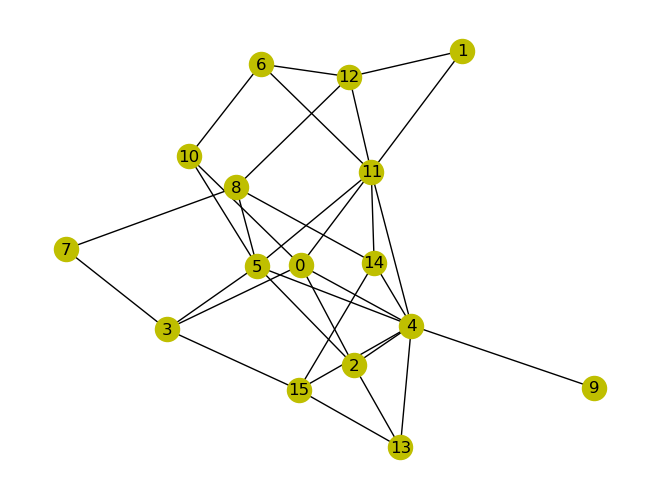

In [3]:
nx.draw(G, **opts)

Compute **all** shortest path lengths with the `shortest_path_length` function provided by `networkx`.

In [4]:
dist = dict(nx.shortest_path_length(G))
dist = [[dist[i][j] for j in range(n)] for i in range(n)]
dist

[[0, 2, 1, 1, 1, 2, 2, 2, 3, 2, 1, 1, 2, 2, 2, 2],
 [2, 0, 3, 3, 2, 2, 2, 3, 2, 3, 3, 1, 1, 3, 2, 3],
 [1, 3, 0, 2, 1, 1, 3, 3, 2, 2, 2, 2, 3, 1, 2, 2],
 [1, 3, 2, 0, 2, 1, 3, 1, 2, 3, 2, 2, 3, 2, 2, 1],
 [1, 2, 1, 2, 0, 1, 2, 3, 2, 1, 2, 1, 2, 1, 1, 1],
 [2, 2, 1, 1, 1, 0, 2, 2, 1, 2, 1, 1, 2, 2, 2, 2],
 [2, 2, 3, 3, 2, 2, 0, 3, 2, 3, 1, 1, 1, 3, 2, 3],
 [2, 3, 3, 1, 3, 2, 3, 0, 1, 4, 3, 3, 2, 3, 2, 2],
 [3, 2, 2, 2, 2, 1, 2, 1, 0, 3, 2, 2, 1, 3, 1, 2],
 [2, 3, 2, 3, 1, 2, 3, 4, 3, 0, 3, 2, 3, 2, 2, 2],
 [1, 3, 2, 2, 2, 1, 1, 3, 2, 3, 0, 2, 2, 3, 3, 3],
 [1, 1, 2, 2, 1, 1, 1, 3, 2, 2, 2, 0, 1, 2, 1, 2],
 [2, 1, 3, 3, 2, 2, 1, 2, 1, 3, 2, 1, 0, 3, 2, 3],
 [2, 3, 1, 2, 1, 2, 3, 3, 3, 2, 3, 2, 3, 0, 2, 1],
 [2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 3, 1, 2, 2, 0, 1],
 [2, 3, 2, 1, 1, 2, 3, 2, 2, 2, 3, 2, 3, 1, 1, 0]]

In [5]:
eccentricity = [max(d) for d in dist]
eccentricity

[3, 3, 3, 3, 3, 2, 3, 4, 3, 4, 3, 3, 3, 3, 3, 3]

`networkx` has a function `eccentricity` which computes a dictionary of eccentricities.

In [6]:
print(nx.eccentricity(G))

{0: 3, 1: 3, 2: 3, 3: 3, 4: 3, 5: 2, 6: 3, 7: 4, 8: 3, 9: 4, 10: 3, 11: 3, 12: 3, 13: 3, 14: 3, 15: 3}


The extreme values of the eccentricity are the **radius** (min) and the **diameter** (max) of the network.

In [7]:
radius = min(eccentricity)
diameter = max(eccentricity)
radius, diameter

(2, 4)

The characteristic path length $L$ is therefore the sum of all entries in $\mathcal{D}$, divided by the number of pairs of distinct nodes $n(n-1)$. 

In [8]:
cpl = sum([sum(d) for d in dist]) / n / (n - 1)
cpl

2.0083333333333333

`networkx` computes $L$ with a function `average_shortest_path_length`.

In [9]:
nx.average_shortest_path_length(G)

2.0083333333333333

Let's compare this with the expected $L=\frac{\ln n}{\langle k \rangle}$. 

In [10]:
from math import log
kavg = sum(dict(G.degree()).values()) / n
log(n) / log(kavg) 

2.0

In [11]:
kavg ## avg degree as expected

4.0

**Definition (Small-world behaviour).**
A network $G = (X, E)$ is said to exhibit a **small world behaviour** if 
its characteristic path length $L$ grows proportionally to the
logarithm of the number $n$ of nodes of $G$:
$$
L \sim \ln n.
$$


In this sense, the ensembles $G(n, m)$ and $G(n, p)$ of random graphs do exhibit small
world behavior (as $n \to \infty$).

## Clustering

In contrast to random graphs, real world networks also contain **many triangles**:  
it is not uncommon that a friend of one of my friends is my friend, too.

This **degree of transitivity** can be measured in several different ways.

**Definition (Graph transitivity).**
Recall that a **triad** is a tree on $3$ nodes or, equivalently, a graph consisting of $2$
adjacent edges (and the nodes they connect).  

The **transitivity** $T$ of a graph $G = (X, E)$
is the proportion of **transitive** triads, i.e., triads which are subgraphs of **triangles**. This proportion can be computed as follows:
$$
T = \frac{3 n_{\Delta}}{n_{\wedge}},
$$
where $n_{\Delta}$ is the number of triangles in $G$, and $n_{\wedge}$ is the number of triads.


By definition, $0 \leq T \leq 1$.

**Example.**

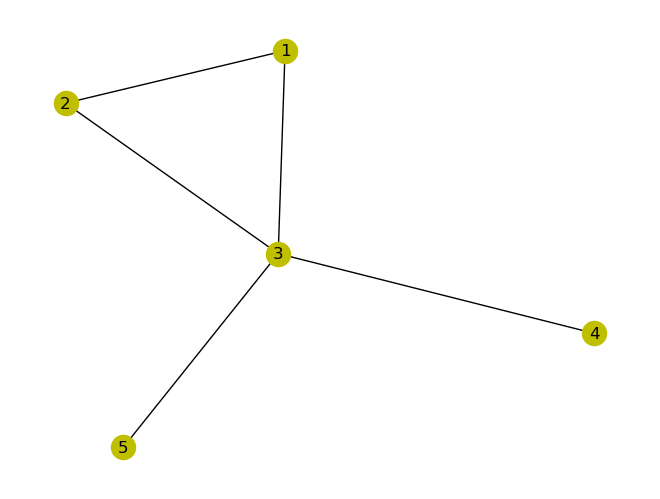

In [12]:
G = nx.Graph(((1,2), (2,3), (3,1), (3,4), (3,5)))
nx.draw(G, **opts)

The function `nx.triangles(G)` returns a `python` dictionary reporting for each node
of the graph `G` the number of triangles it is contained in.

In [13]:
print(nx.triangles(G))

{1: 1, 2: 1, 3: 1, 4: 0, 5: 0}


Overall, each triangle in `G` is thus accounted for $3$ times, once for each of its
vertices.  Hence, the following sum determines this number $3 n_{\Delta}$.

In [14]:
triple_nr_triangles = sum(nx.triangles(G).values())
print(triple_nr_triangles)

3


As we've seen, the number $n_{\wedge}$ of triads in `G` can be determined from the graph's degree
sequence, as each node of degree $k$ is the central node of exactly
$\binom{k}{2}$ triads.  

In [15]:
print(G.degree())
print({k : v * (v-1) // 2 for k, v in dict(G.degree()).items()})
nr_triads = sum([v * (v-1) // 2 for v in dict(G.degree()).values()])
nr_triads

[(1, 2), (2, 2), (3, 4), (4, 1), (5, 1)]
{1: 1, 2: 1, 3: 6, 4: 0, 5: 0}


8

The transitivity $T$ of `G` is the quotient of these two quantities, $T = 3 n_{\Delta}/n_{\wedge}$,
which `networkx` computes with a function `transitivity`.

In [16]:
print(triple_nr_triangles / nr_triads )
print(nx.transitivity(G))

0.375
0.375


* The transitivity of a $G(n, p)$ **random graph** is
$$
T = p,
$$
the probability of any edge as third edge in a triangle.

(Or: Compute $3 n_{\Delta}/n_{\wedge}$ using the explicit formulas
from the previous lecture: $n_{\Delta} = \binom{n}{3}p^3$ and $n_{\wedge} = 3 \binom{n}{3}p^2$.)

##  Code Corner

### `networkx`

* `shortest_path_length` : [[doc]](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.generic.shortest_path_length.html)


* `eccentricity`: [[doc]](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.distance_measures.eccentricity.html)


* `triangles`: [[doc]](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cluster.triangles.html)


* `transitivity`: [[doc]](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cluster.transitivity.html)


* `clustering`: [[doc]](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cluster.clustering.html)


* `average_clustering`: [[doc]](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cluster.average_clustering.html)

##  Exercises

1. What are the characteristic path length $L$, the transitivity $T$, and the clustering coefficient $C$
of the Peterson graph?

1. What are the characteristic path length $L$, the transitivity $T$, and the clustering coefficient $C$
of the Florentine families marital graph?

2. What is the transitivity and what is the clustering coefficient
of a complete graph on $n$ nodes?

3. What is the transitivity and what is the clustering coefficient
of a tree on $n$ nodes?

